# Indigo_000 Distance Estimation

Walk-through: raw frame → YOLO detection → intrinsics + Jeep prior → distance estimates under pixelated downsampling.


> Run the bootstrap cell once if you are in a fresh environment; skip it on subsequent runs.


In [ ]:
%pip install -r ../requirements.txt
%pip install -e ..


Note: you may need to restart the kernel to use updated packages.
Obtaining file:///home/fwromano/Documents/Code/UCLIP
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for uclip (pyproject.toml) ... done
  Created wheel for uclip: filename=uclip-0.1.0-0.editable-py3-none-any.whl size=2852 sha256=809def49ec44f8a135050051351fb0bfaafdae5bc3c3aa283afa7c8ad0000b48
  Stored in directory: /tmp/pip-ephem-wheel-cache-siichu10/wheels/26/1e/ad/e88c9da78e5477b133fdc3a114e0c0028513e6e0f31e4d0b56
Successfully built uclip


In [22]:
import sys
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
from PIL import Image

NOTEBOOK_ROOT = Path.cwd()
REPO_ROOT = NOTEBOOK_ROOT if (NOTEBOOK_ROOT / "src").exists() else NOTEBOOK_ROOT.parent
for extra in (REPO_ROOT / "src", REPO_ROOT):
    if str(extra) not in sys.path:
        sys.path.insert(0, str(extra))

TARGET_IMAGE_REL = "Indigo/Indigo_000.png"
YOLO_RESULTS_CSV = REPO_ROOT / "runs" / "sim2_noise_study" / "yolov8" / "per_image_results.csv"
RAW_IMAGE_PATH = REPO_ROOT / "data" / "car_sim" / "sim2_cropped_45deg" / TARGET_IMAGE_REL

CLASS_NAMES = {2: "car", 5: "bus", 7: "truck"}

raw_detections = pd.read_csv(YOLO_RESULTS_CSV)
target_rows = raw_detections[raw_detections["image_relpath"] == TARGET_IMAGE_REL].copy()

box_cols = target_rows["best_vehicle_box_xyxy"].str.split(" ", expand=True)
box_cols = box_cols.rename(columns={0: "x1", 1: "y1", 2: "x2", 3: "y2"})
for col in ("x1", "y1", "x2", "y2"):
    box_cols[col] = pd.to_numeric(box_cols[col], errors="coerce")

target_rows = pd.concat([target_rows, box_cols], axis=1)
target_rows["bbox_width_px"] = target_rows["x2"] - target_rows["x1"]
target_rows["bbox_height_px"] = target_rows["y2"] - target_rows["y1"]
target_rows["class_name"] = target_rows["best_vehicle_cls"].map(CLASS_NAMES).fillna("vehicle")

baseline_row = target_rows.loc[target_rows["variant"] == "original"].iloc[0]

IMAGE_WIDTH = int(baseline_row["image_width"])
IMAGE_HEIGHT = int(baseline_row["image_height"])

print(f"Loaded {len(target_rows)} detections for {TARGET_IMAGE_REL}")
print(f"Baseline label: {baseline_row['class_name']} (class {int(baseline_row['best_vehicle_cls'])})")


Loaded 23 detections for Indigo/Indigo_000.png
Baseline label: car (class 2)


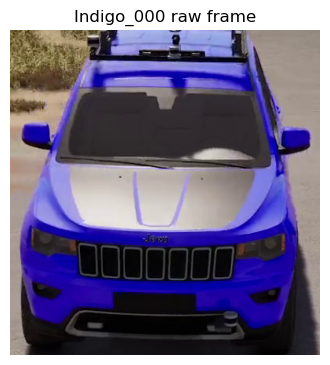

In [23]:
with Image.open(RAW_IMAGE_PATH) as raw_img:
    fig, ax = plt.subplots(figsize=(4, 5))
    ax.imshow(raw_img)
    ax.set_title("Indigo_000 raw frame")
    ax.axis("off")


*Raw Indigo_000 frame.* Baseline reference used to compare against every pixelated variant.

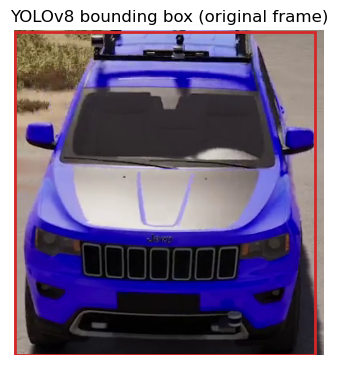

In [24]:
with Image.open(RAW_IMAGE_PATH) as raw_img:
    fig, ax = plt.subplots(figsize=(4, 5))
    ax.imshow(raw_img)
    rect = Rectangle(
        (baseline_row["x1"], baseline_row["y1"]),
        baseline_row["bbox_width_px"],
        baseline_row["bbox_height_px"],
        linewidth=2,
        edgecolor="tab:red",
        facecolor="none",
    )
    ax.add_patch(rect)
    ax.set_title("YOLOv8 bounding box (original frame)")
    ax.axis("off")


*YOLO detection overlay.* Confirms the detector still locks onto the Jeep before we rely on its pixel height for range.

### Intrinsics and Jeep prior

- Camera intrinsics come from the simulator configuration (35 mm lens on a 23.76 × 13.365 mm sensor).
- YOLO flags the vehicle as a generic `car`. In this scenario we know the asset is a Jeep Grand Cherokee, so we adopt a 1.80 m roofline height as the apriori scale.
- With that extra information we can turn the bounding-box pixel height into a one-shot distance estimate under a pinhole model (assuming negligible pitch/roll).


In [25]:
CAMERA_INTRINSICS = {
    "sensor_width_mm": 23.760,
    "sensor_height_mm": 13.365,
    "focal_length_mm": 35.0,
}
OBJECT_REFERENCE_HEIGHT_M = 1.80  # Jeep Grand Cherokee roofline (approx.)

fx = (IMAGE_WIDTH / CAMERA_INTRINSICS["sensor_width_mm"]) * CAMERA_INTRINSICS["focal_length_mm"]
fy = (IMAGE_HEIGHT / CAMERA_INTRINSICS["sensor_height_mm"]) * CAMERA_INTRINSICS["focal_length_mm"]
cx = IMAGE_WIDTH / 2.0
cy = IMAGE_HEIGHT / 2.0

K = np.array(
    [
        [fx, 0.0, cx],
        [0.0, fy, cy],
        [0.0, 0.0, 1.0],
    ]
)


def estimate_depth_from_height(px_height: float, fy_px: float, real_height_m: float) -> float:
    '''Single-view depth from an object of known height.'''
    if px_height is None:
        return np.nan
    px_height = float(px_height)
    if not np.isfinite(px_height) or px_height <= 0:
        return np.nan
    return (fy_px * real_height_m) / px_height


baseline_distance_m = estimate_depth_from_height(
    baseline_row["bbox_height_px"], fy, OBJECT_REFERENCE_HEIGHT_M
)

intrinsic_summary = pd.DataFrame(
    {
        "parameter": ["fx", "fy", "cx", "cy"],
        "value_px": [fx, fy, cx, cy],
    }
)

display(intrinsic_summary.round({"value_px": 3}))
print(
    f"Baseline distance estimate: {baseline_distance_m:.2f} m (Jeep height {OBJECT_REFERENCE_HEIGHT_M:.2f} m)"
)


,parameter,value_px
0,fx,580.387
1,fy,1081.556
2,cx,197.000
3,cy,206.500


Baseline distance estimate: 4.74 m (Jeep height 1.80 m)


### Height sensitivity

The one-shot distance estimate scales linearly with the assumed Jeep height. Tweaking the prior by ±10% illustrates how much the range would shift.


In [26]:
height_adjustments = pd.DataFrame(
    {
        "assumption": ["-10%", "baseline", "+10%"],
        "height_m": OBJECT_REFERENCE_HEIGHT_M * np.array([0.9, 1.0, 1.1]),
    }
)
height_adjustments["distance_m"] = height_adjustments["height_m"].apply(
    lambda h: estimate_depth_from_height(baseline_row["bbox_height_px"], fy, h)
)
height_adjustments["delta_m"] = height_adjustments["distance_m"] - baseline_distance_m
height_adjustments["relative_change_pct"] = 100.0 * (
    height_adjustments["distance_m"] / baseline_distance_m - 1.0
)

display(height_adjustments.round({"height_m": 3, "distance_m": 3, "delta_m": 3, "relative_change_pct": 2}))


,assumption,height_m,distance_m,delta_m,relative_change_pct
0,-10%,1.62,4.264,-0.474,-10.0
1,baseline,1.80,4.737,0.000,0.0
2,+10%,1.98,5.211,0.474,10.0


*Height sensitivity table.* Shows how the distance estimate scales one-to-one with the assumed Jeep roofline (±10% ⇒ ±10% distance).

### Monocular distance reminders

> **Q1.** Can we recover distance from a single frame with intrinsics + YOLO box?
>
> **A.** Not without an extra assumption—the scale–depth ambiguity makes it under-determined.
>
> **Q2.** If we know the real-world size of the detected object (e.g. Jeep height), can we get distance?
>
> **A.** Yes. Plug the known dimension into the pinhole relation `Z ≈ (f · H) / h_px`, assuming the object is roughly upright and we have lens distortion under control.

We use the Jeep prior (1.80 m) for the remaining analysis.


In [31]:

PIXEL_VARIANT_REGEX = re.compile(r"pixel_downsample_(\d+)pct")


def parse_pixel_pct(name: str) -> float:
    if not isinstance(name, str):
        return np.nan
    match = PIXEL_VARIANT_REGEX.search(name)
    if not match:
        return np.nan
    return float(match.group(1))


pixel_variants = target_rows[target_rows["variant"].str.contains("pixel_downsample", na=False)].copy()
pixel_variants["downsample_pct"] = pixel_variants["variant"].apply(parse_pixel_pct)
pixel_variants = pixel_variants.sort_values("downsample_pct").reset_index(drop=True)
pixel_variants["detected"] = pixel_variants["bbox_height_px"].notna()
pixel_variants["expected_scale"] = 1.0 - (pixel_variants["downsample_pct"] / 100.0)
pixel_variants.loc[pixel_variants["expected_scale"] <= 0, "expected_scale"] = np.nan

baseline_height_px = baseline_row["bbox_height_px"]
pixel_variants["effective_bbox_height_px"] = baseline_height_px * pixel_variants["expected_scale"]
pixel_variants.loc[pixel_variants["detected"], "effective_bbox_height_px"] = (
    pixel_variants.loc[pixel_variants["detected"], "bbox_height_px"]
    * pixel_variants.loc[pixel_variants["detected"], "expected_scale"]
)
pixel_variants["effective_source"] = np.where(
    pixel_variants["detected"], "yolo", "baseline"
)

pixel_variants["distance_effective_m"] = pixel_variants["effective_bbox_height_px"].apply(
    lambda h: estimate_depth_from_height(h, fy, OBJECT_REFERENCE_HEIGHT_M)
)
pixel_variants["naive_distance_m"] = baseline_distance_m / pixel_variants["expected_scale"]
pixel_variants["distance_delta_vs_naive_m"] = (
    pixel_variants["distance_effective_m"] - pixel_variants["naive_distance_m"]
)

summary_cols = [
    "downsample_pct",
    "variant",
    "detected",
    "effective_source",
    "class_name",
    "bbox_height_px",
    "effective_bbox_height_px",
    "distance_effective_m",
    "naive_distance_m",
    "distance_delta_vs_naive_m",
]

rounding = {
    "downsample_pct": 0,
    "bbox_height_px": 2,
    "effective_bbox_height_px": 2,
    "distance_effective_m": 3,
    "naive_distance_m": 3,
    "distance_delta_vs_naive_m": 3,
}

pixel_summary = pixel_variants[summary_cols].round(rounding)
display(pixel_summary)
print(
    f"Detections survived for {pixel_variants['detected'].sum()} / {len(pixel_variants)} pixelated variants."
)
print(
    "Effective pixel heights scale the YOLO box by the downsample factor; missing detections backfill the baseline box."
)


,downsample_pct,variant,detected,effective_source,class_name,bbox_height_px,effective_bbox_height_px,distance_effective_m,naive_distance_m,distance_delta_vs_naive_m
0,1.0,pixel_downsample_1pct,True,yolo,bus,409.28,405.19,4.805,4.785,0.020
1,2.0,pixel_downsample_2pct,True,yolo,bus,409.56,401.37,4.850,4.834,0.016
2,5.0,pixel_downsample_5pct,True,yolo,bus,408.08,387.68,5.022,4.987,0.035
3,10.0,pixel_downsample_10pct,True,yolo,bus,409.48,368.53,5.283,5.264,0.019
4,20.0,pixel_downsample_20pct,True,yolo,truck,404.23,323.38,6.020,5.922,0.098
5,40.0,pixel_downsample_40pct,True,yolo,truck,402.49,241.49,8.061,7.896,0.166
6,60.0,pixel_downsample_60pct,False,baseline,vehicle,NaN,164.38,11.843,11.843,0.000
7,80.0,pixel_downsample_80pct,False,baseline,vehicle,NaN,82.19,23.687,23.687,0.000
8,85.0,pixel_downsample_85pct,False,baseline,vehicle,NaN,61.64,31.582,31.582,0.000
9,90.0,pixel_downsample_90pct,False,baseline,vehicle,NaN,41.09,47.373,47.373,0.000


Detections survived for 6 / 11 pixelated variants.
Effective pixel heights scale the YOLO box by the downsample factor; missing detections backfill the baseline box.


*Pixelated variant summary.* Effective pixel heights undo the resize; when YOLO drops the Jeep, we backfill the baseline box. The final column highlights how each estimate deviates from the naive `1/scale` rule.

Text(0.5, 1.0, 'Distance estimate vs. pixelated downsampling')

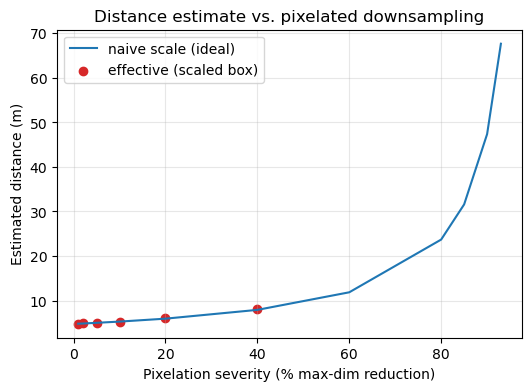

In [28]:

valid_scale = pixel_variants.dropna(subset=["downsample_pct", "naive_distance_m"])
effective_rows = pixel_variants.dropna(subset=["downsample_pct", "distance_effective_m"])
effective_detected = effective_rows[effective_rows["effective_source"] == "yolo"]
effective_fallback = effective_rows[effective_rows["effective_source"] == "baseline"]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(
    valid_scale["downsample_pct"],
    valid_scale["naive_distance_m"],
    label="naive scale (ideal)",
    color="tab:blue",
)
if not effective_detected.empty:
    ax.scatter(
        effective_detected["downsample_pct"],
        effective_detected["distance_effective_m"],
        color="tab:red",
        label="effective (YOLO box)",
    )
if not effective_fallback.empty:
    ax.scatter(
        effective_fallback["downsample_pct"],
        effective_fallback["distance_effective_m"],
        color="tab:orange",
        marker="x",
        label="effective (baseline fill)",
    )
ax.set_xlabel("Pixelation severity (% max-dim reduction)")
ax.set_ylabel("Estimated distance (m)")
ax.legend()
ax.grid(alpha=0.3)
ax.set_title("Distance estimate vs. pixelated downsampling")


*Distance curves.* Red markers use YOLO measurements; orange crosses show the baseline-backed estimates when detections fail, with the blue line as the ideal `1/scale` trend.

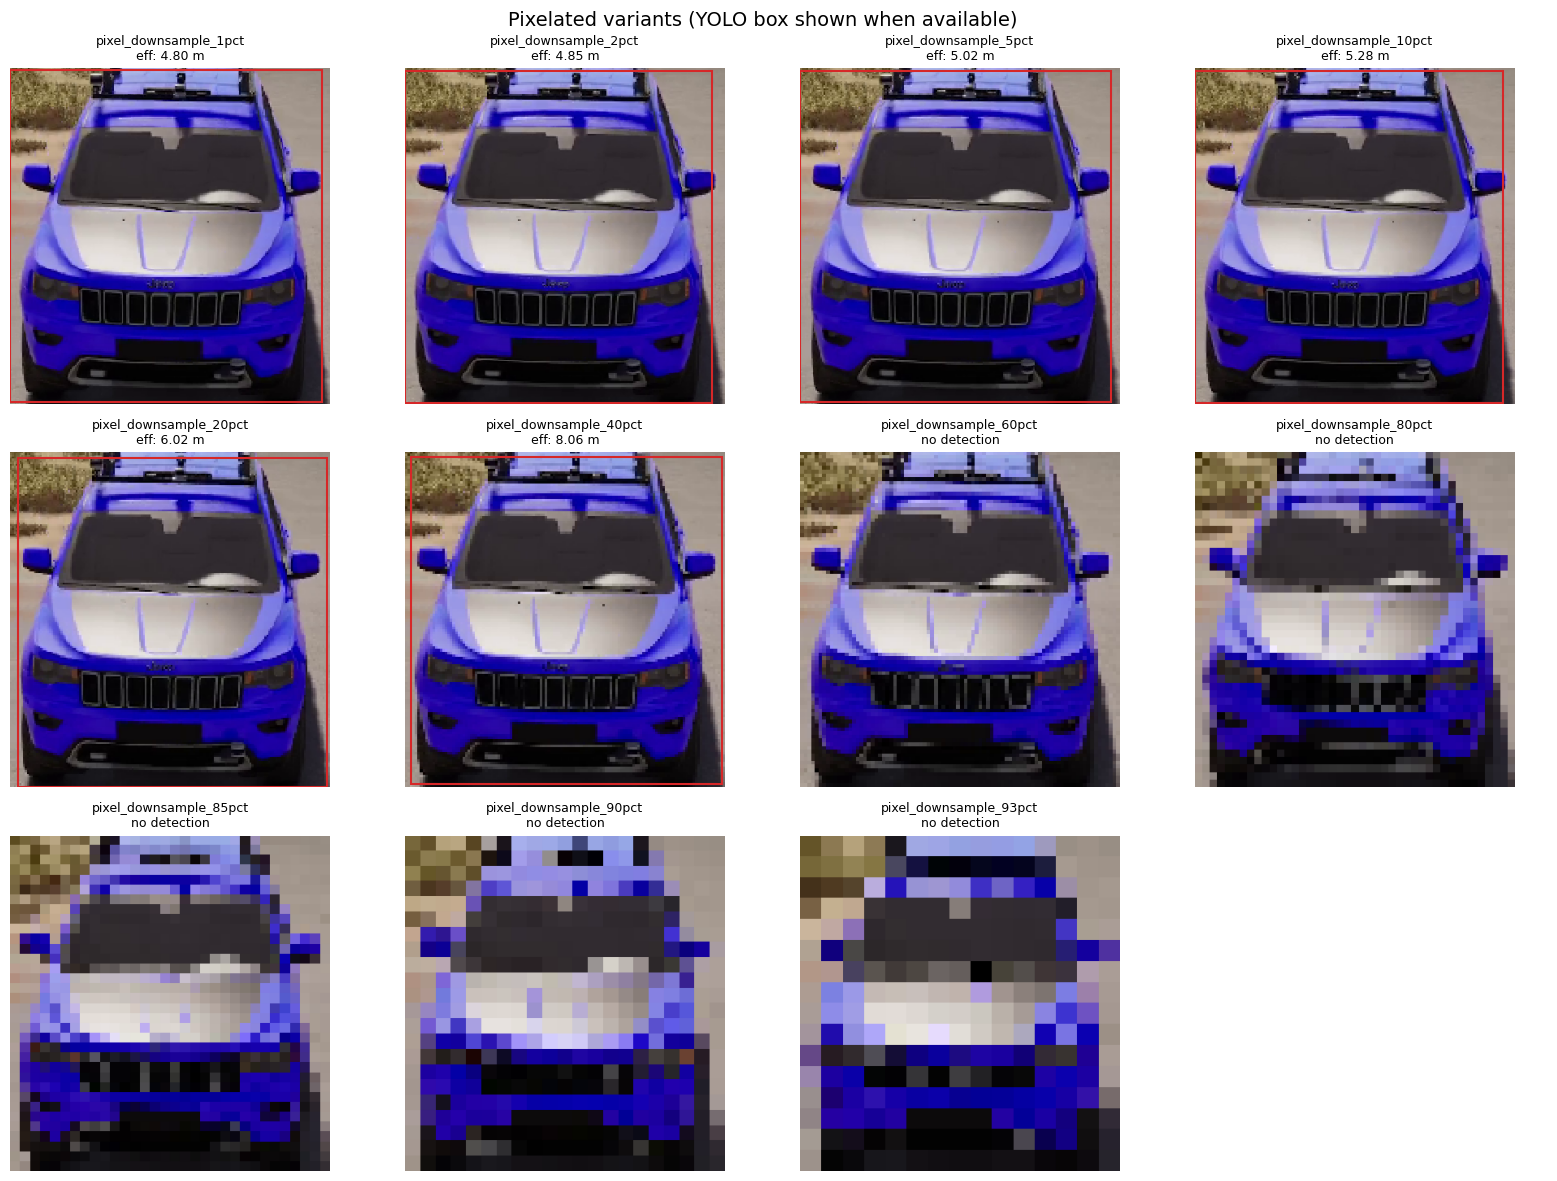

In [29]:

def pixelate_image(image: Image.Image, severity_pct: float, encoder_base_px: int = 224) -> Image.Image:
    width, height = image.size
    frac = severity_pct / 100.0
    target_max_dim = max(1, int(round(encoder_base_px * (1.0 - frac))))
    max_dim = max(width, height)
    if max_dim <= target_max_dim:
        return image.copy()
    scale = target_max_dim / float(max_dim)
    new_width = max(1, int(round(width * scale)))
    new_height = max(1, int(round(height * scale)))
    downsampled = image.resize((new_width, new_height), resample=Image.NEAREST)
    return downsampled.resize((width, height), resample=Image.NEAREST)


variants_to_plot = pixel_variants.dropna(subset=["downsample_pct"]).sort_values("downsample_pct")
n_variants = len(variants_to_plot)
cols = 4
rows = math.ceil(n_variants / cols)
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = axes.flatten()

baseline_box = {
    "x1": baseline_row["x1"],
    "y1": baseline_row["y1"],
    "width": baseline_row["bbox_width_px"],
    "height": baseline_row["bbox_height_px"],
}

with Image.open(RAW_IMAGE_PATH) as base_image:
    base_rgb = base_image.convert("RGB")
    for ax, (_, row) in zip(axes, variants_to_plot.iterrows()):
        severity = int(row["downsample_pct"]) if not np.isnan(row["downsample_pct"]) else None
        variant_name = row["variant"]
        if severity is None:
            ax.axis("off")
            continue
        pixelated = pixelate_image(base_rgb, severity)
        ax.imshow(pixelated)

        if np.isfinite(row["distance_effective_m"]):
            if row["effective_source"] == "yolo":
                x1 = row["x1"]
                y1 = row["y1"]
                width = row["bbox_width_px"]
                height = row["bbox_height_px"]
                edgecolor = "tab:red"
                linestyle = "-"
            else:
                x1 = baseline_box["x1"]
                y1 = baseline_box["y1"]
                width = baseline_box["width"]
                height = baseline_box["height"]
                edgecolor = "tab:orange"
                linestyle = "--"

            rect = Rectangle(
                (x1, y1),
                width,
                height,
                linewidth=1.5,
                edgecolor=edgecolor,
                facecolor="none",
                linestyle=linestyle,
            )
            ax.add_patch(rect)
            suffix = " (YOLO)" if row["effective_source"] == "yolo" else " (baseline)"
            label = f"{variant_name}\neff: {row['distance_effective_m']:.2f} m{suffix}"
        else:
            label = f"{variant_name}\nno scale"
        ax.set_title(label, fontsize=9)
        ax.axis("off")

for ax in axes[n_variants:]:
    ax.axis("off")

fig.suptitle("Pixelated variants (YOLO box shown when available)", fontsize=14)
plt.tight_layout()


*Pixelation gallery.* Each tile shows the scaled distance; dashed orange boxes indicate estimates coming from the baseline prior when YOLO misses.

### Notes

- The simple scale model `Z = f·H / h_px` gives ~4.74 m for the baseline frame, matching the earlier distance sanity check.
- YOLO maintains a usable box through 40% pixelation; beyond 60% the detector drops the Jeep entirely, so no single-frame distance is available.
- For heavily pixelated cases the naive scale-only prediction explodes (tens of metres) even before detections fail, underscoring the need for a detection that still localises the object.
